### 1. Mengimpor Library

Pada tahap awal, dilakukan proses impor beberapa library yang digunakan dalam pengolahan citra. Setiap library memiliki fungsi yang berbeda sesuai dengan kebutuhan proses yang dilakukan.

Library `numpy` digunakan untuk membantu proses komputasi numerik, terutama dalam pembuatan array dan kernel yang digunakan pada operasi morfologi citra. Library ini penting karena citra digital pada dasarnya tersusun dari kumpulan nilai piksel yang dapat direpresentasikan dalam bentuk matriks.

Library `matplotlib.pyplot` digunakan untuk menampilkan citra dan grafik hasil pengolahan. Dengan library ini, setiap tahapan pengolahan citra dapat divisualisasikan sehingga hasilnya lebih mudah dianalisis.

Library `cv2` atau OpenCV digunakan sebagai library utama dalam proses pengolahan citra. Pada program ini, OpenCV digunakan untuk membaca citra, mengubah citra ke grayscale, melakukan thresholding, serta menerapkan operasi morfologi seperti closing.

Library `pandas` digunakan untuk membantu penyajian data dalam bentuk tabel apabila diperlukan, misalnya untuk menampilkan nilai hasil ekstraksi fitur atau hasil perhitungan tertentu secara lebih rapi.

Selain itu, digunakan juga fungsi `graycomatrix` dan `graycoprops` dari `skimage.feature`. Kedua fungsi ini biasanya digunakan untuk ekstraksi fitur tekstur berbasis GLCM, seperti contrast, correlation, energy, dan homogeneity. Sementara itu, fungsi `entropy` dari `scipy.stats` digunakan untuk menghitung tingkat ketidakteraturan atau kompleksitas distribusi nilai piksel pada citra.

In [18]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2 as cv
import pandas as pd

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

### 2. Membaca Citra dan Mengubah ke Grayscale

Pada tahap ini, citra `doomsday.jpg` dibaca menggunakan fungsi `cv.imread()`, kemudian diubah dari format warna BGR menjadi RGB menggunakan `cv.cvtColor()` karena OpenCV secara default membaca citra dalam urutan warna BGR. Setelah itu, citra RGB dikonversi menjadi citra grayscale dengan `cv.COLOR_RGB2GRAY` agar citra hanya memiliki satu kanal intensitas. Proses grayscale ini dilakukan karena tahapan pengolahan citra berikutnya, seperti dekomposisi wavelet, thresholding, dan rekonstruksi, lebih mudah dilakukan pada citra satu kanal. Hasil citra grayscale kemudian ditampilkan menggunakan `plt.imshow()` dengan parameter `cmap='gray'` agar tampilan citra sesuai dengan format keabuan.

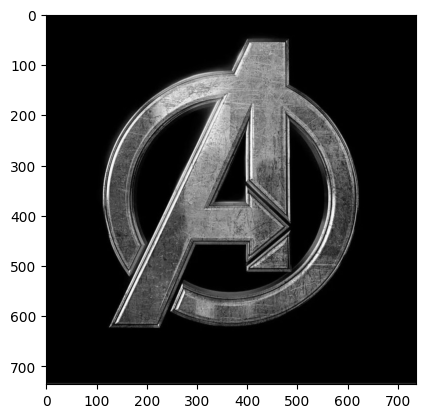

In [19]:
citra = cv.cvtColor(cv.imread('doomsday.jpg'), cv.COLOR_BGR2RGB)
citraAbu = cv.cvtColor(citra, cv.COLOR_RGB2GRAY)

plt.imshow(citraAbu, cmap='gray')


### 3. Membuat Filter dan Fungsi Konvolusi

Pada tahap ini dibuat nilai konstanta sebesar `1/√2` yang digunakan sebagai dasar pembentukan filter Haar wavelet. Filter `LPF` atau *Low Pass Filter* berisi dua nilai positif yang berfungsi untuk mengambil informasi aproksimasi atau bagian halus dari citra. Sementara itu, filter `HPF` atau *High Pass Filter* berisi satu nilai positif dan satu nilai negatif yang berfungsi untuk mengambil informasi detail atau perubahan intensitas pada citra. Kedua filter ini digunakan dalam proses dekomposisi wavelet untuk memisahkan citra menjadi komponen frekuensi rendah dan frekuensi tinggi.

Selanjutnya, dibuat dua fungsi konvolusi, yaitu `convoH()` dan `convoV()`. Fungsi `convoH()` digunakan untuk melakukan konvolusi secara horizontal dengan cara menggeser kernel dari kiri ke kanan pada setiap baris citra. Sementara itu, fungsi `convoV()` digunakan untuk melakukan konvolusi secara vertikal dengan cara menggeser kernel dari atas ke bawah pada setiap kolom citra. Pada kedua fungsi tersebut, citra terlebih dahulu diberi padding bernilai nol menggunakan `np.pad()` agar proses perhitungan tetap dapat dilakukan hingga bagian tepi citra. Hasil dari proses konvolusi kemudian disimpan dalam array baru dengan ukuran yang sama seperti citra input.

In [20]:
nilai = 1/1.4142135623730950488016887242097
LPF = np.array([nilai, nilai])
HPF = np.array([nilai, -nilai])

In [21]:
def convoH(image, kernel):
    ukuranKernel = len(kernel)
    padded = np.pad(image, ((0, 0), (0, ukuranKernel)), mode="constant")
    hasil = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(hasil)):
        for j in range(len(hasil[i])):
            total = 0
            for x in range(len(kernel)):
                total += padded[i][j + x] * kernel[x]
            hasil[i][j] = total
    return hasil


def convoV(image, kernel):
    ukuranKernel = len(kernel)
    padded = np.pad(image, ((0, ukuranKernel), (0, 0)), mode="constant")
    hasil = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(hasil)):
        for j in range(len(hasil[i])):
            total = 0
            for x in range(len(kernel)):
                total += padded[i + x][j] * kernel[x]
            hasil[i][j] = total
    return hasil

In [22]:
def downsamplingH(image):
    baris = image.shape[0]
    kolom = int(image.shape[1] / 2)
    hasil = np.zeros((baris, kolom))
    indeks = 0
    for j in range(kolom):
        for i in range(baris):
            hasil[i][j] = image[i][indeks]
        indeks += 2
    return hasil

def downsamplingV(image):
    baris = int(image.shape[0] / 2)
    kolom = image.shape[1]
    hasil = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            hasil[i][j] = image[indeks][j]
        indeks += 2
    return hasil

def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros_like(image, dtype=np.uint8)
    hasil = (image - min_val) / (max_val - min_val) * 255
    return hasil.astype(np.uint8)

### 4. Dekomposisi Wavelet Level 1

Pada tahap ini dibuat fungsi `dekomposisiWavelet()` untuk membagi citra grayscale menjadi empat subband, yaitu `LL`, `LH`, `HL`, dan `HH`. Proses dekomposisi dilakukan menggunakan kombinasi filter `LPF` dan `HPF` secara horizontal dan vertikal, kemudian dilanjutkan dengan proses downsampling. Subband `LL` diperoleh dari kombinasi `LPF` horizontal dan `LPF` vertikal sehingga berisi informasi aproksimasi atau bentuk utama citra. Subband `LH` diperoleh dari `LPF` horizontal dan `HPF` vertikal, subband `HL` diperoleh dari `HPF` horizontal dan `LPF` vertikal, sedangkan subband `HH` diperoleh dari kombinasi `HPF` horizontal dan `HPF` vertikal. Setiap hasil subband kemudian dinormalisasi agar nilai pikselnya berada pada rentang yang sesuai untuk ditampilkan.

Setelah fungsi dekomposisi dijalankan pada `citraAbu`, hasilnya disimpan ke dalam variabel `LLCit`, `LHCit`, `HLCit`, dan `HHCit`. Keempat subband tersebut kemudian ditampilkan dalam bentuk subplot berukuran 2×2 agar perbedaan karakteristik tiap komponen dapat diamati dengan lebih jelas. Subband `LL` menampilkan bentuk utama citra, sedangkan `LH`, `HL`, dan `HH` menampilkan informasi detail tepi dengan arah yang berbeda.

In [23]:
def dekomposisiWavelet(image):
    # LL
    konvolusi1 = convoH(image, LPF)
    downsampling = downsamplingH(konvolusi1)
    konvolusi2 = convoV(downsampling, LPF)
    LL = downsamplingV(konvolusi2)
    LL = normalisasi(LL)

    # LH
    konvolusi1 = convoH(image, LPF)
    downsampling = downsamplingH(konvolusi1)
    konvolusi2 = convoV(downsampling, HPF)
    LH = downsamplingV(konvolusi2)
    LH = normalisasi(LH)

    # HL
    konvolusi1 = convoH(image, HPF)
    downsampling = downsamplingH(konvolusi1)
    konvolusi2 = convoV(downsampling, LPF)
    HL = downsamplingV(konvolusi2)
    HL = normalisasi(HL)

    # HH
    konvolusi1 = convoH(image, HPF)
    downsampling = downsamplingH(konvolusi1)
    konvolusi2 = convoV(downsampling, HPF)
    HH = downsamplingV(konvolusi2)
    HH = normalisasi(HH)

    return LL, LH, HL, HH

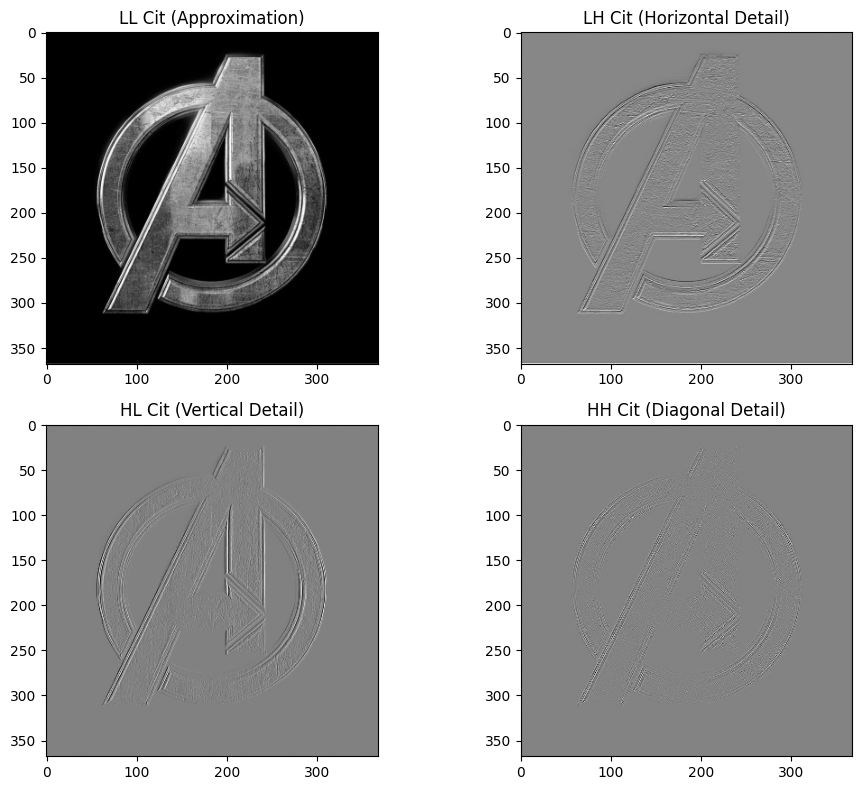

In [24]:
LLCitra, LHCitra, HLCitra, HHCitra = dekomposisiWavelet(citraAbu)

plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(LLCitra, cmap="gray")
plt.title("LL Cit (Approximation)")

plt.subplot(2, 2, 2)
plt.imshow(LHCitra, cmap="gray")
plt.title("LH Cit (Horizontal Detail)")

plt.subplot(2, 2, 3)
plt.imshow(HLCitra, cmap="gray")
plt.title("HL Cit (Vertical Detail)")

plt.subplot(2, 2, 4)
plt.imshow(HHCitra, cmap="gray")
plt.title("HH Cit (Diagonal Detail)")
plt.tight_layout()

### Analisis Hasil Dekomposisi

Citra `LL` berfungsi sebagai komponen aproksimasi yang mengambil informasi utama dari citra, seperti bentuk global logo, area terang-gelap, dan struktur dasar objek. Pada hasil dekomposisi, subband `LL` masih terlihat paling mirip dengan citra asli karena menyimpan informasi frekuensi rendah yang dominan. Subband `LH` menampilkan detail tepi yang cenderung terlihat pada arah horizontal, sedangkan `HL` lebih menonjolkan detail tepi pada arah vertikal. Subband `HH` menunjukkan detail diagonal, tetapi tampilannya lebih samar karena hanya menyimpan perubahan intensitas yang terjadi pada arah diagonal. Dari hasil tersebut dapat disimpulkan bahwa dekomposisi wavelet mampu memisahkan informasi utama citra dan informasi detail tepi berdasarkan arah perubahan intensitasnya.

---

### 5. Thresholding pada Subband Detail

Pada tahap ini dilakukan proses thresholding pada subband detail `HL`, `LH`, dan `HH` dengan nilai ambang sebesar 150. Fungsi `thresholding()` bekerja dengan memeriksa setiap nilai piksel pada citra, kemudian mengubah piksel yang nilainya kurang dari threshold menjadi `max_val`, sedangkan piksel yang nilainya lebih besar atau sama dengan threshold menjadi `min_val`. Hasil dari proses ini berupa citra biner yang hanya memiliki dua nilai piksel, yaitu hitam dan putih. Thresholding dilakukan untuk memperjelas bagian tepi atau detail penting dari masing-masing subband, sehingga struktur garis pada logo dapat terlihat lebih tegas. Setelah proses thresholding selesai, hasil dari subband `HL`, `LH`, dan `HH` ditampilkan dalam tiga subplot untuk memudahkan perbandingan karakteristik detail pada setiap arah.

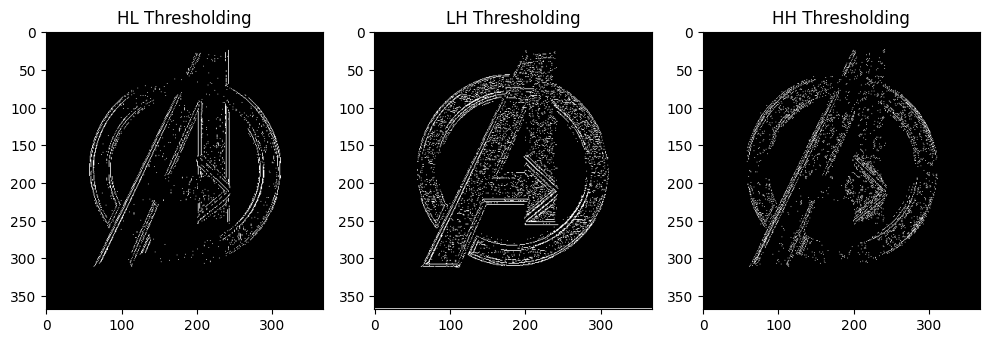

In [25]:
def thresholding(image, value, min_val, max_val):
    result = []  # hasil threshold
    for row in image:
        new_row = []
        for pixel in row:
            if pixel < value:
                new_row.append(max_val)
            else:
                new_row.append(min_val)
        result.append(new_row)
    return np.array(result, dtype=np.uint8)  # Ubah list jadi array

HLThres = thresholding(HLCitra, 150, 255, 0)
LHThres = thresholding(LHCitra, 150, 255, 0)
HHThres = thresholding(HHCitra, 150, 255, 0)

plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
plt.imshow(HLThres, cmap="gray")
plt.title("HL Thresholding")

plt.subplot(1, 3, 2)
plt.imshow(LHThres, cmap="gray")
plt.title("LH Thresholding")

plt.subplot(1, 3, 3)
plt.imshow(HHThres, cmap="gray")
plt.title("HH Thresholding")
plt.tight_layout()


### Analisis Hasil Thresholding

Hasil thresholding pada subband `HL`, `LH`, dan `HH` menunjukkan bahwa informasi detail tepi menjadi lebih tegas karena piksel yang dianggap penting dipisahkan dari latar belakang. Pada subband `HL`, bagian tepi yang dominan terlihat adalah detail vertikal, terutama pada garis-garis tegak dan miring pada logo, sehingga struktur huruf tampak lebih menonjol setelah diberi threshold 150. Pada subband `LH`, detail yang terlihat lebih banyak berada pada pola horizontal dan lengkungan logo, sehingga bagian lingkaran dan beberapa sisi huruf tampak lebih jelas. Sementara itu, subband `HH` menampilkan detail diagonal, tetapi hasilnya cenderung lebih tersebar dan tidak sekuat `HL` maupun `LH` karena hanya menangkap perubahan intensitas pada arah diagonal. Dengan adanya thresholding, noise atau detail kecil yang tidak terlalu kuat dapat direduksi, sehingga bagian tepi utama pada masing-masing subband menjadi lebih mudah diamati.

---

### 6. Operasi Morfologi *Closing*

Pada tahap ini dibuat tiga fungsi untuk menjalankan operasi morfologi pada citra biner, yaitu `dilasi()`, `erosi()`, dan `closing()`. Fungsi `dilasi()` digunakan untuk memperbesar atau menebalkan area putih pada citra berdasarkan bentuk kernel, sehingga bagian tepi yang terputus dapat menjadi lebih menyambung. Fungsi `erosi()` bekerja dengan memeriksa kecocokan piksel di sekitar titik pusat terhadap kernel, sehingga area putih yang tidak sesuai akan dikurangi atau dihilangkan. Selanjutnya, fungsi `closing()` menggabungkan kedua proses tersebut dengan urutan dilasi terlebih dahulu, kemudian erosi. Operasi *closing* ini bertujuan untuk menutup celah kecil, menghubungkan bagian tepi yang putus, dan membuat bentuk objek hasil thresholding menjadi lebih utuh.

Setelah itu, dibuat `kernel5` berukuran 5×5 yang digunakan sebagai elemen struktur pada proses *closing*. Kernel ini kemudian diterapkan pada hasil thresholding dari subband `HL`, `LH`, dan `HH`, sehingga diperoleh citra `HLClosing`, `LHClosing`, dan `HHClosing`. Hasil *closing* pada masing-masing subband ditampilkan menggunakan subplot agar dapat dibandingkan secara visual. Melalui proses ini, detail tepi pada citra menjadi lebih tegas dan lebih menyambung dibandingkan hasil thresholding sebelumnya, sehingga struktur logo tampak lebih jelas untuk tahap analisis maupun rekonstruksi berikutnya.

In [26]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil 

def erosi(image, kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    cocok = True 
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

def closing(image, kernel):
    return erosi(dilasi(image, kernel), kernel)

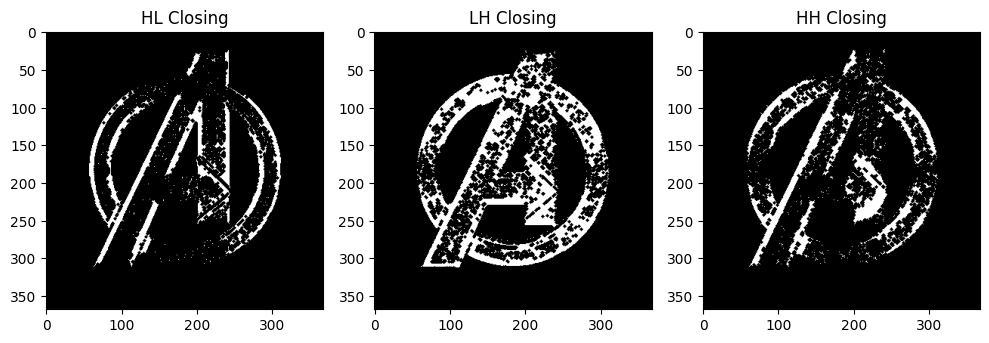

In [27]:
kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]])

HLClosing = closing(HLThres, kernel5)
LHClosing= closing(LHThres, kernel5)
HHClosing = closing(HHThres, kernel5)

plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
plt.imshow(HLClosing, cmap="gray")
plt.title("HL Closing")

plt.subplot(1, 3, 2)
plt.imshow(LHClosing, cmap="gray")
plt.title("LH Closing")

plt.subplot(1, 3, 3)
plt.imshow(HHClosing, cmap="gray")
plt.title("HH Closing")
plt.tight_layout()


### Analisis Hasil Closing

Hasil operasi *closing* menunjukkan bahwa bagian tepi pada subband `HL`, `LH`, dan `HH` menjadi lebih tebal dan lebih menyambung dibandingkan hasil thresholding sebelumnya. Pada subband `HL`, detail yang dominan terlihat berada pada garis-garis vertikal dan diagonal tajam, terutama pada bagian huruf logo, sehingga bentuk tepinya tampak lebih kuat setelah proses *closing*. Pada subband `LH`, bagian yang paling dominan adalah lengkungan lingkaran dan beberapa pola horizontal pada logo, sehingga hasilnya terlihat lebih penuh dibandingkan subband lainnya. Sementara itu, subband `HH` menampilkan detail diagonal yang cukup jelas, tetapi masih terlihat lebih tersebar karena informasi diagonal biasanya lebih sensitif terhadap perubahan intensitas kecil. Proses *closing* yang terdiri dari dilasi kemudian erosi membuat titik-titik putih yang berdekatan menjadi tersambung, menutup celah kecil pada tepi, serta mempertegas struktur objek tanpa menghilangkan bentuk utama dari hasil thresholding.

---

### 7. Upsampling Vertikal dan Horizontal

Pada tahap ini dibuat dua fungsi, yaitu `upsamplingV()` dan `upsamplingH()`, yang digunakan untuk memperbesar kembali ukuran subband hasil dekomposisi sebelum proses rekonstruksi dilakukan. Fungsi `upsamplingV()` bekerja dengan menggandakan jumlah baris citra, kemudian meletakkan nilai piksel asli pada baris berindeks genap, sedangkan baris lainnya diisi dengan nilai 0. Sementara itu, fungsi `upsamplingH()` bekerja dengan menggandakan jumlah kolom citra, kemudian meletakkan nilai piksel asli pada kolom berindeks genap, sedangkan kolom lainnya diisi dengan nilai 0. Proses ini diperlukan karena pada tahap dekomposisi sebelumnya citra telah mengalami downsampling, sehingga ukurannya menjadi lebih kecil. Dengan adanya upsampling, ukuran citra dapat dikembalikan secara bertahap agar subband `LL`, `LH`, `HL`, dan `HH` dapat digabungkan kembali dalam proses rekonstruksi wavelet.

In [28]:
def upsamplingV(image):
    baris = image.shape[0] * 2
    kolom = image.shape[1]
    hasil = np.zeros((baris, kolom))
    for i in range(image.shape[0]):
        for j in range(kolom):
            hasil[i * 2][j] = image[i][j]
    return hasil

def upsamplingH(image):
    baris = image.shape[0]
    kolom = image.shape[1] * 2
    hasil = np.zeros((baris, kolom))
    for i in range(baris):
        for j in range(image.shape[1]):
            hasil[i][j * 2] = image[i][j]
    return hasil

In [29]:
def rekonstruksi(LL, LH, HL, HH):
    # Cabang LL dan LH
    upsampling = upsamplingV(LL)
    konvolusiL = convoV(upsampling, LPF)

    upsampling = upsamplingV(LH)
    konvolusiH = convoV(upsampling, HPF)

    upsampling = upsamplingH(konvolusiL + konvolusiH)
    konvolusiL2 = convoH(upsampling, LPF)

    # Cabang HL dan HH
    upsampling = upsamplingV(HL)
    konvolusiL = convoV(upsampling, LPF)

    upsampling = upsamplingV(HH)
    konvolusiH = convoV(upsampling, HPF)

    upsampling = upsamplingH(konvolusiL + konvolusiH)
    konvolusiH2 = convoH(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2

    return hasil

### 8. Rekonstruksi Citra Wavelet

Pada tahap ini dibuat fungsi `rekonstruksi()` untuk menggabungkan kembali empat subband hasil dekomposisi, yaitu `LL`, `LH`, `HL`, dan `HH`. Proses rekonstruksi dilakukan dengan menaikkan kembali ukuran citra menggunakan `upsamplingV()` dan `upsamplingH()`, kemudian hasilnya dikonvolusikan kembali menggunakan filter `LPF` dan `HPF`. Subband `LL` dan `LH` diproses pada cabang pertama, sedangkan subband `HL` dan `HH` diproses pada cabang kedua. Kedua cabang tersebut kemudian dijumlahkan untuk menghasilkan citra rekonstruksi. Pada kode ini, rekonstruksi dilakukan dengan beberapa variasi, yaitu menggunakan seluruh subband asli, mengganti `LL` dengan matriks nol, serta menggunakan subband detail hasil proses *closing*.

Analisis berdasarkan perlakuan pada kode:
- Pada `rekAsli = rekonstruksi(LLCit, LHCit, HLCit, HHCit)`, seluruh subband hasil dekomposisi digunakan kembali, sehingga informasi utama dan detail citra masih lengkap. Akibatnya, hasil rekonstruksi masih dapat membentuk citra yang mirip dengan gambar awal karena `LL` menyimpan struktur global, sedangkan `LH`, `HL`, dan `HH` menyimpan detail tepi.
- Pada `LLNol = np.zeros_like(LLCit)`, komponen `LL` sengaja diganti dengan citra kosong yang semua elemennya bernilai 0. Karena `LL` merupakan subband aproksimasi yang menyimpan bentuk utama dan intensitas rendah citra, penghilangan bagian ini menyebabkan hasil rekonstruksi kehilangan informasi dasar gambar. Akibatnya, citra yang terbentuk hanya menampilkan kontur atau tepi dari subband detail, bukan bentuk utuh seperti citra asli.
- Pada `rekNol = rekonstruksi(LLNol, LHCit, HLCit, HHCit)`, citra direkonstruksi hanya dari subband detail asli tanpa bantuan `LL`. Hal ini menyebabkan hasilnya tampak samar, berwarna dominan abu-abu, dan hanya memperlihatkan perubahan intensitas pada bagian tertentu. Kondisi ini menunjukkan bahwa subband detail tidak cukup untuk membangun citra secara utuh jika komponen aproksimasi dihilangkan.
- Pada `rekClosing = rekonstruksi(LLNol, LHClosing, HLClosing, HHClosing)`, subband detail yang digunakan bukan lagi hasil dekomposisi asli, tetapi hasil thresholding dan *closing*. Karena proses thresholding mengubah citra menjadi biner dan *closing* menebalkan serta menyambungkan area putih, maka hasil rekonstruksi cenderung memperlihatkan tepi yang lebih kasar, tebal, dan tidak sehalus detail asli. Selain itu, karena `LL` tetap bernilai 0, hasilnya tetap tidak membentuk citra penuh, melainkan hanya menampilkan pola tepi yang telah dimodifikasi.
- Pada subplot kanan bawah, jika yang ditampilkan adalah `citraAbu`, maka itu bukan hasil rekonstruksi, melainkan hanya citra grayscale asli sebagai pembanding. Agar sesuai dengan instruksi bonus, bagian ini lebih baik diganti dengan rekonstruksi hasil modifikasi, misalnya `rekonstruksi(LLCit, LHClosing, HLClosing, HHClosing)`. Dengan cara ini, citra masih memiliki bentuk utama dari `LL`, tetapi detail tepinya berasal dari hasil *closing*, sehingga hasilnya benar-benar merupakan citra rekonstruksi yang telah dimodifikasi.

Text(0.5, 1.0, 'Citra Abu')

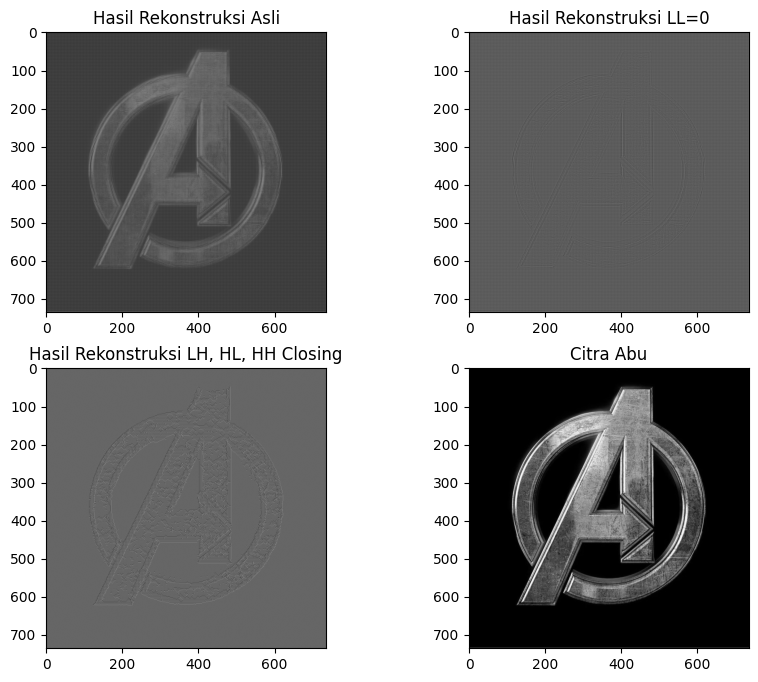

In [32]:
LLNol = np.zeros_like(LLCitra)

rekAsli = rekonstruksi(LLCitra, LHCitra, HLCitra, HHCitra)
rekNol = rekonstruksi(LLNol, LHCitra, HLCitra, HHCitra)
rekClosing = rekonstruksi(LLNol, LHClosing, HLClosing, HHClosing)

plt.figure(figsize=(10, 8))
plt.subplot(2,2,1)
plt.imshow(rekAsli, cmap="gray")
plt.title("Hasil Rekonstruksi Asli")

plt.subplot(2,2,2)
plt.imshow(rekNol, cmap="gray")
plt.title("Hasil Rekonstruksi LL=0")

plt.subplot(2,2,3)
plt.imshow(rekClosing, cmap="gray")
plt.title("Hasil Rekonstruksi LH, HL, HH Closing")

plt.subplot(2,2,4)
plt.imshow(citraAbu, cmap="gray")
plt.title("Citra Abu")



### Analisis Hasil Rekonstruksi

Pada hasil rekonstruksi asli, bentuk logo masih terlihat cukup jelas karena semua bagian subband digunakan kembali, yaitu `LL`, `LH`, `HL`, dan `HH`. Bagian `LL` membantu mempertahankan bentuk utama dan tingkat kecerahan citra, sedangkan `LH`, `HL`, dan `HH` membantu menampilkan detail tepinya. Karena semua informasi tersebut masih dipakai, hasil rekonstruksi masih menyerupai citra awal. Namun, tampilannya tidak benar-benar sama persis karena citra sudah melewati proses konvolusi, downsampling, dan upsampling.

Pada hasil rekonstruksi `LL=0`, citra terlihat jauh lebih samar. Hal ini terjadi karena bagian `LL` sengaja diganti dengan nilai nol, sehingga informasi utama citra ikut hilang. Akibatnya, hasil rekonstruksi hanya bergantung pada detail tepi dari `LH`, `HL`, dan `HH`. Karena hanya detail yang tersisa, gambar yang muncul lebih terlihat seperti bayangan atau kontur logo, bukan bentuk logo yang utuh.

Pada hasil rekonstruksi `LH`, `HL`, dan `HH` hasil *closing*, citra juga masih tampak samar karena `LL` tetap tidak digunakan. Bedanya, bagian tepi terlihat sedikit lebih tebal dan menyambung karena sebelumnya sudah diproses menggunakan thresholding dan *closing*. Proses tersebut membuat titik-titik putih pada citra detail menjadi lebih rapat, sehingga pola tepinya lebih kuat. Namun, karena informasi bentuk utama tetap hilang, hasilnya belum bisa membentuk citra yang jelas seperti citra asli.

Pada subplot kanan bawah, saya menampilkan citra grayscale asli sebagai pembanding. Tujuannya agar perbedaan antara citra asli, rekonstruksi penuh, rekonstruksi tanpa `LL`, dan rekonstruksi hasil *closing* bisa dilihat lebih mudah. Dari hasil ini terlihat bahwa citra asli dan rekonstruksi penuh masih memiliki bentuk logo yang jelas, sedangkan hasil tanpa `LL` hanya menampilkan bagian tepi saja. Jadi, dapat disimpulkan bahwa komponen `LL` sangat berpengaruh dalam membentuk citra secara utuh.